# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset di ambil dari reosritory publik di kaggel (dataset pistachio).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
# Memuat data dari file Excel Pistachio
import os
import pandas as pd

# Memuat data dari file Excel Pistachio
# Jalur ke folder dataset fitur tabel
dataset_dir = "../pistachio_raw/Pistachio_16_Features_Dataset"

print("Isi folder fitur:", os.listdir(dataset_dir))

file_path = os.path.join(dataset_dir, "Pistachio_16_Features_Dataset.xlsx")
df = pd.read_excel(file_path)

print("\n--- 5 Data Teratas Dataset Pistachio ---")
df.head()

Isi folder fitur: ['Pistachio_16_Features_Dataset.arff', 'Pistachio_16_Features_Dataset.xls', 'Pistachio_16_Features_Dataset.xlsx', 'Pistachio_16_Features_Dataset_Citation_Request.txt']

--- 5 Data Teratas Dataset Pistachio ---


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
0,63391,1568.405,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,0.3238,0.7278,0.0062,0.0037,0.5297,0.8734,Kirmizi_Pistachio
1,68358,1942.187,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,0.2277,0.7181,0.0060,0.0034,0.5156,0.9024,Kirmizi_Pistachio
2,73589,1246.538,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,0.5951,0.6767,0.0061,0.0030,0.4579,0.9391,Kirmizi_Pistachio
3,71106,1445.261,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,0.4278,0.7005,0.0060,0.0030,0.4907,0.9755,Kirmizi_Pistachio
4,80087,1251.524,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,0.6425,0.6803,0.0059,0.0028,0.4628,0.9833,Kirmizi_Pistachio


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Struktur Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           2148 non-null   int64  
 1   PERIMETER      2148 non-null   float64
 2   MAJOR_AXIS     2148 non-null   float64
 3   MINOR_AXIS     2148 non-null   float64
 4   ECCENTRICITY   2148 non-null   float64
 5   EQDIASQ        2148 non-null   float64
 6   SOLIDITY       2148 non-null   float64
 7   CONVEX_AREA    2148 non-null   int64  
 8   EXTENT         2148 non-null   float64
 9   ASPECT_RATIO   2148 non-null   float64
 10  ROUNDNESS      2148 non-null   float64
 11  COMPACTNESS    2148 non-null   float64
 12  SHAPEFACTOR_1  2148 non-null   float64
 13  SHAPEFACTOR_2  2148 non-null   float64
 14  SHAPEFACTOR_3  2148 non-null   float64
 15  SHAPEFACTOR_4  2148 non-null   float64
 16  Class          2148 non-null   object 
dtypes: float64(14), i

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17748\1324327561.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


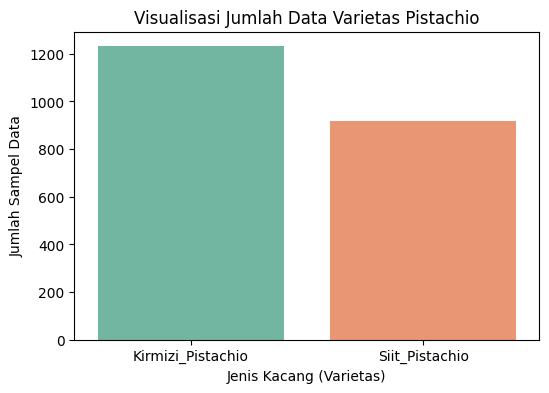

In [7]:
print("--- Informasi Struktur Dataset ---")
df.info()

print("\n--- Memeriksa Data yang Kosong (Missing Values) ---")
print(df.isnull().sum())

# Menghitung jumlah data per jenis kacang
jumlah_kelas = df['Class'].value_counts()
print("\n--- Jumlah Data Per Jenis Kacang ---")
print(jumlah_kelas)

# Membuat grafik visualisasi jumlah varietas
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Visualisasi Jumlah Data Varietas Pistachio')
plt.xlabel('Jenis Kacang (Varietas)')
plt.ylabel('Jumlah Sampel Data')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Class'])
y = df['Class']

# 2. Encoding Data Target (Mengubah teks menjadi angka 0 dan 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Membagi Dataset menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("--- Tahap Preprocessing Selesai ---")
print(f"Ukuran X_train (Data Latihan): {X_train.shape}")
print(f"Ukuran X_test (Data Pengujian): {X_test.shape}")
print(f"Keterangan Target: Angka 0 = {le.classes_[0]}, Angka 1 = {le.classes_[1]}")

--- Tahap Preprocessing Selesai ---
Ukuran X_train (Data Latihan): (1718, 16)
Ukuran X_test (Data Pengujian): (430, 16)
Keterangan Target: Angka 0 = Kirmizi_Pistachio, Angka 1 = Siit_Pistachio


# **6. Modeling**

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi Model AI menggunakan Random Forest
model_pistachio = RandomForestClassifier(n_estimators=100, random_state=42)

print("--- Memulai Proses Latihan (Training) Model AI ---")
model_pistachio.fit(X_train, y_train)
print("✅ Proses latihan selesai! Model AI sudah berhasil dibuat.")

--- Memulai Proses Latihan (Training) Model AI ---
✅ Proses latihan selesai! Model AI sudah berhasil dibuat.


# **7. Evaluation**

--- AKURASI MODEL AI: 88.60% ---

--- Laporan Klasifikasi (Classification Report) ---
                   precision    recall  f1-score   support

Kirmizi_Pistachio       0.90      0.89      0.90       244
   Siit_Pistachio       0.86      0.88      0.87       186

         accuracy                           0.89       430
        macro avg       0.88      0.88      0.88       430
     weighted avg       0.89      0.89      0.89       430



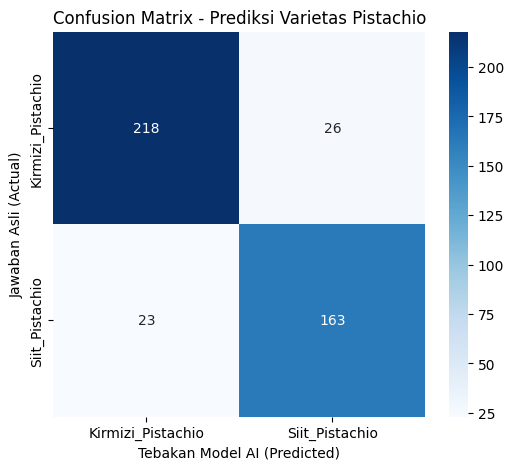

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_prediksi = model_pistachio.predict(X_test)
akurasi = accuracy_score(y_test, y_prediksi)
print(f"--- AKURASI MODEL AI: {akurasi * 100:.2f}% ---\n")

print("--- Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_test, y_prediksi, target_names=le.classes_))

# Menampilkan Grafik Confusion Matrix
cm = confusion_matrix(y_test, y_prediksi)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Prediksi Varietas Pistachio')
plt.ylabel('Jawaban Asli (Actual)')
plt.xlabel('Tebakan Model AI (Predicted)')
plt.show()